# Iterate Paper Assessment Prompt

This notebook iterates on the paper assessment prompt, using the 250 annotated notes from the dev set. The final prompt is evaluated on the 250 annotations from the test set

In [1]:
import pandas as pd
import sys
sys.path.append("../")
from dotenv import load_dotenv
load_dotenv()

from src.llm_utils import LLM_wrapper, PaperAssessment
from src.llm_utils import PAPER_ASSESSMENT_PROMPT as paper_assessment_prompt

In [2]:
MODEL_NAME = "gpt-5.2-2025-12-11"
CONTEXT_WINDOW = 395000 # gpt 5.2's context window is 400k tokens

In [3]:
llm_wrapper = LLM_wrapper(
    model_name=MODEL_NAME,
    system_prompt=paper_assessment_prompt,
    output_format_class=PaperAssessment
)

In [4]:
df_pred = llm_wrapper.assess_dataframe(
    input_file_path="../data/02_paper_assessment/gt_paper_assessment.csv",
    text_column="full_text",
    output_dir="../data/02_paper_assessment/"
)

Loading checkpoint from ../data/02_paper_assessment/checkpoints/20260102_1707_gpt-5.2-2025-12-11.checkpoint.csv
Total rows: 500, Already processed: 500, Remaining (after filter): 0


0it [00:00, ?it/s]

Processing complete. Final results saved.


In [5]:
df_pred

,Unnamed: 0,PMID,full_text,gt_in_scope,gt_has_repo,gt_repo_url,generation,is_match,reason,country_first_author_institution,repo_url,code_statement_locations,code_statement_sentence
0,0,36904233,==== Front\nNutrients\nNutrients\nnutrients\nN...,Yes,No,NaN,True,True,The study develops a new multivariable predict...,Argentina,NaN,NaN,NaN
1,1,36911893,==== Front\nPerm J\ntpj\ntpj\nThe Permanente J...,Yes,No,NaN,True,True,Yes. The study develops and internally validat...,United States of America,NaN,NaN,NaN
2,2,36935582,==== Front\nJ Int Med Res\nJ Int Med Res\nIMR\...,Yes,No,NaN,True,True,Yes. This retrospective clinical study develop...,China,NaN,NaN,NaN
3,3,37017968,==== Front\nJAMA Netw Open\nJAMA Netw Open\nJA...,Yes,Yes,https://github.com/mgregorich/BEAt-DKD_PredeGFR,True,True,This prognostic study develops and externally ...,Austria,https://github.com/mgregorich/BEAt-DKD_PredeGFR,['discussion'],The code for model development and validation ...
4,4,36384245,==== Front\nClin Exp Emerg Med\nClin Exp Emerg...,Yes,No,NaN,True,True,The study develops a new multivariable predict...,Italy,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,36866292,==== Front\nArthrosc Sports Med Rehabil\nArthr...,No,NaN,NaN,True,False,This article is a methods/clinical commentary ...,United States of America,NaN,NaN,NaN
496,496,36128836,==== Front\nCancer Med\nCancer Med\n10.1002/(I...,Yes,No,NaN,True,True,This is an external validation study comparing...,China,NaN,NaN,NaN
497,497,36874135,==== Front\nFront Oncol\nFront Oncol\nFront. O...,Yes,Yes,https://github.com/putzfn/HNLNL_autosegmentati...,True,True,The study develops and temporally externally v...,Germany,https://github.com/putzfn/HNLNL_autosegmentati...,"['methods', 'data_availability_section']",We also share the trained models and the suppl...
498,498,36936595,==== Front\nBMJ Med\nBMJ Med\nbmjmed\nbmjmed\n...,Yes,No,NaN,True,True,This is an external validation cohort study ev...,United Kingdom,NaN,NaN,NaN


In [6]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

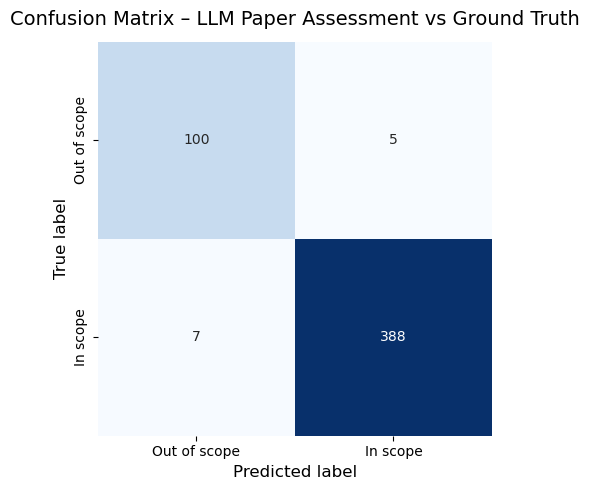

              precision    recall  f1-score   support

Out of scope       0.93      0.95      0.94       105
    In scope       0.99      0.98      0.98       395

    accuracy                           0.98       500
   macro avg       0.96      0.97      0.96       500
weighted avg       0.98      0.98      0.98       500

Cohen’s κ: 0.928


In [7]:
# Convert to booleans
df_pred["is_match"] = (
    df_pred["is_match"].astype(str).str.strip().str.lower().map({"true": True, "false": False})
)
df_pred["gt_in_scope"] = (
    df_pred["gt_in_scope"].astype(str).str.strip().str.lower().map({"yes": True, "no": False})
)

df_pred = df_pred.dropna(subset=["is_match", "gt_in_scope"])

# --- Compute confusion matrix ---
cm = confusion_matrix(df_pred["gt_in_scope"], df_pred["is_match"])
labels = ["Out of scope", "In scope"]

# --- Plot heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    square=True,
)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.title("Confusion Matrix – LLM Paper Assessment vs Ground Truth", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# --- Optional metrics ---
print(classification_report(df_pred["gt_in_scope"], df_pred["is_match"], target_names=labels))
print(f"Cohen’s κ: {cohen_kappa_score(df_pred['gt_in_scope'], df_pred['is_match']):.3f}")

Subset size (in-scope only): 393


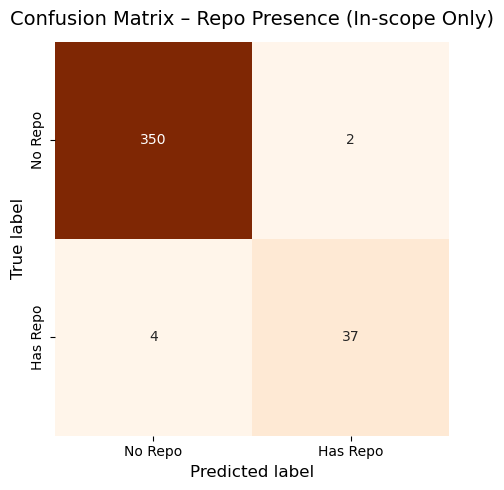

Classification Report:
              precision    recall  f1-score   support

     No Repo       0.99      0.99      0.99       352
    Has Repo       0.95      0.90      0.93        41

    accuracy                           0.98       393
   macro avg       0.97      0.95      0.96       393
weighted avg       0.98      0.98      0.98       393

Cohen’s κ: 0.917

Exact URL matches (pred == gt): 34/41 ground-truth repos (82.9%)


In [8]:
# --- Normalize string columns ---
df_pred["gt_repo_url"] = df_pred["gt_repo_url"].astype(str).str.strip().str.lower().replace({"nan": ""})
df_pred["repo_url"] = df_pred["repo_url"].astype(str).str.strip().str.lower().replace({"nan": ""})

# --- Create binary indicators ---
df_pred["has_repo_gt"] = df_pred["repo_url"].apply(lambda x: bool(x))
df_pred["has_repo_pred"] = df_pred["gt_repo_url"].apply(lambda x: bool(x))

# --- Exact match indicator (for analysis) ---
df_pred["repo_match_exact"] = df_pred.apply(
    lambda r: r["gt_repo_url"] == r["repo_url"] if r["has_repo_gt"] and r["has_repo_pred"] else False,
    axis=1
)

# --- Filter to in-scope only ---
subset = df_pred[df_pred["is_match"] == True].copy()
print(f"Subset size (in-scope only): {len(subset)}")

# --- Compute confusion matrix for repo presence ---
cm = confusion_matrix(subset["has_repo_gt"], subset["has_repo_pred"])
labels = ["No Repo", "Has Repo"]

# --- Plot confusion matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    square=True,
)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.title("Confusion Matrix – Repo Presence (In-scope Only)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# --- Compute metrics ---
print("Classification Report:")
print(classification_report(subset["has_repo_gt"], subset["has_repo_pred"], target_names=labels))
print(f"Cohen’s κ: {cohen_kappa_score(subset['has_repo_gt'], subset['has_repo_pred']):.3f}")

# --- (Optional) Report URL-level exact matches ---
exact_matches = subset["repo_match_exact"].sum()
print(f"\nExact URL matches (pred == gt): {exact_matches}/{subset['has_repo_gt'].sum()} ground-truth repos ({exact_matches/subset['has_repo_gt'].sum():.1%})")

In [15]:
# --------------------------------------------------
# False Positives and False Negatives (in-scope only)
# --------------------------------------------------

fp = subset.loc[
    (subset["has_repo_pred"] == True) & (subset["has_repo_gt"] == False)
]

fn = subset.loc[
    (subset["has_repo_pred"] == False) & (subset["has_repo_gt"] == True)
]

print(f"False Positives: {len(fp)}")
print(f"False Negatives: {len(fn)}")

# Select columns you likely care about
cols_to_show = [
    "PMID",          # or PMID if that’s your identifier
    "repo_url",
    "gt_repo_url",
    "has_repo_pred",
    "has_repo_gt",
    "repo_match_exact",
]

display(fp[cols_to_show].sort_values("PMID"))
display(fn[cols_to_show].sort_values("PMID"))

False Positives: 2
False Negatives: 4


,PMID,repo_url,gt_repo_url,has_repo_pred,has_repo_gt,repo_match_exact
123,39130111,,https://seakheeoh76.shinyapps.io/xgboost_ba_pr...,True,False,False
204,40216893,,https://www.cdc.gov/nchs/nhanes/index.htm,True,False,False


,PMID,repo_url,gt_repo_url,has_repo_pred,has_repo_gt,repo_match_exact
420,35534601,appendix,,False,True,False
116,39022171,https://github.com/tran031194/abpmml,,False,True,False
185,39990546,appendix,,False,True,False
211,40313554,appendix,,False,True,False


In [9]:
df_pred.loc[df_pred["repo_url"].ne("none"), ["PMID", "repo_url", "gt_repo_url"]]

,PMID,repo_url,gt_repo_url
0,36904233,,
1,36911893,,
2,36935582,,
3,37017968,https://github.com/mgregorich/beat-dkd_predegfr,https://github.com/mgregorich/beat-dkd_predegfr
4,36384245,,
...,...,...,...
495,36866292,,
496,36128836,,
497,36874135,https://github.com/putzfn/hnlnl_autosegmentati...,https://github.com/putzfn/hnlnl_autosegmentati...
498,36936595,,


In [10]:
df_pred

,Unnamed: 0,PMID,full_text,gt_in_scope,gt_has_repo,gt_repo_url,generation,is_match,reason,country_first_author_institution,repo_url,code_statement_locations,code_statement_sentence,has_repo_gt,has_repo_pred,repo_match_exact
0,0,36904233,==== Front\nNutrients\nNutrients\nnutrients\nN...,True,No,,True,True,The study develops a new multivariable predict...,Argentina,,NaN,NaN,False,False,False
1,1,36911893,==== Front\nPerm J\ntpj\ntpj\nThe Permanente J...,True,No,,True,True,Yes. The study develops and internally validat...,United States of America,,NaN,NaN,False,False,False
2,2,36935582,==== Front\nJ Int Med Res\nJ Int Med Res\nIMR\...,True,No,,True,True,Yes. This retrospective clinical study develop...,China,,NaN,NaN,False,False,False
3,3,37017968,==== Front\nJAMA Netw Open\nJAMA Netw Open\nJA...,True,Yes,https://github.com/mgregorich/beat-dkd_predegfr,True,True,This prognostic study develops and externally ...,Austria,https://github.com/mgregorich/beat-dkd_predegfr,['discussion'],The code for model development and validation ...,True,True,True
4,4,36384245,==== Front\nClin Exp Emerg Med\nClin Exp Emerg...,True,No,,True,True,The study develops a new multivariable predict...,Italy,,NaN,NaN,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,36866292,==== Front\nArthrosc Sports Med Rehabil\nArthr...,False,NaN,,True,False,This article is a methods/clinical commentary ...,United States of America,,NaN,NaN,False,False,False
496,496,36128836,==== Front\nCancer Med\nCancer Med\n10.1002/(I...,True,No,,True,True,This is an external validation study comparing...,China,,NaN,NaN,False,False,False
497,497,36874135,==== Front\nFront Oncol\nFront Oncol\nFront. O...,True,Yes,https://github.com/putzfn/hnlnl_autosegmentati...,True,True,The study develops and temporally externally v...,Germany,https://github.com/putzfn/hnlnl_autosegmentati...,"['methods', 'data_availability_section']",We also share the trained models and the suppl...,True,True,True
498,498,36936595,==== Front\nBMJ Med\nBMJ Med\nbmjmed\nbmjmed\n...,True,No,,True,True,This is an external validation cohort study ev...,United Kingdom,,NaN,NaN,False,False,False


In [11]:
df_pred["country_first_author_institution"].value_counts()

country_first_author_institution
China                        151
United Kingdom                52
United States of America      50
Netherlands                   44
Canada                        25
Australia                     20
Germany                       17
Italy                         15
Japan                         12
Spain                         12
Switzerland                   11
Denmark                       10
Republic of Korea              9
Thailand                       7
France                         7
Korea, Republic of             5
Belgium                        5
India                          5
Sweden                         4
Greece                         3
New Zealand                    3
Brazil                         3
Indonesia                      2
Ethiopia                       2
Finland                        2
Lebanon                        2
Taiwan                         2
Iran                           2
Singapore                      2
Pakistan  

In [12]:
df_pred["code_statement_locations"].value_counts()

code_statement_locations
['data_availability_section']                              11
['methods']                                                 9
['code_availability_section']                               6
['methods', 'data_availability_section']                    3
['other']                                                   2
['supplementary_material']                                  2
['code_availability_section', 'supplementary_material']     2
['discussion']                                              1
['data_availability_section', 'supplementary_material']     1
['results', 'supplementary_material']                       1
['data_availability_section', 'methods']                    1
['methods', 'supplementary_material']                       1
['results']                                                 1
Name: count, dtype: int64

In [13]:
df_pred["code_statement_sentence"].value_counts()

code_statement_sentence
The code for model development and validation without the data, and the code for the shiny app (for R software) are openly available in the GitHub repository at BEAt-DKD_PredeGFR.          1
The source code for this work has been provided for open access through an online repository:                                                                                                1
The code is available for replication                                                                                                                                                        1
Code will be made public after the publication of this work at                                                                                                                               1
All code used in this paper, the final model and a calculator is available in online                                                                                                         1
The code used to cond

In [16]:
df_pred.to_csv("../data/02_paper_assessment/evaluation_paper_assessment.csv", index=False)